# JavaScript Vulnerability Detection — Full Pipeline
### Cross-Dataset Generalization Study (Ferenc et al. + Viszkok et al.)

This notebook runs the complete pipeline we designed:

1. Load both datasets, extract repo identity, find the true repo-level overlap
2. Deduplicate overlapping functions, build **Dataset A** (44 shared metrics, all repos) and **Dataset B** (78 columns, 73-repo overlap only)
3. Correlation recap (quick sanity check — you already generated the full plots separately)
4. Imbalance-handling utilities: class weights, focal loss, SMOTE, Gaussian noise resampling
5. Evaluation metrics helper (accuracy, F1, PR-AUC, MCC)
6. Baseline classical models (XGBoost, Random Forest, Bagging) with **repo-grouped** cross-validation
7. Stacked CNN model (reusing your existing VGG16/19/AlexNet/ResNet/LSTM architecture)
8. In-distribution results summary
9. **Headline experiment:** train on the 73-repo pool, test on the 20 repos held out entirely
10. Secondary experiment: does adding Viszkok's extra 34 process-metric columns help, within the 73-repo overlap?
11. Final comparison table + generalization-gap plot

**Important:** put `JSVulnerabilityDataSet-1_0.csv` and `pm_uom_all_full.csv` in the same folder as this notebook before running.


In [1]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    average_precision_score, matthews_corrcoef, classification_report
)
from xgboost import XGBClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Deep learning (stacked CNN) — requires tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LSTM
)
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

pd.set_option("display.max_columns", 100)


## Step 1 — Load data, identify repo overlap

Every repo in Viszkok's file also appears in Ferenc's file (confirmed earlier). Ferenc has 93
total repos, Viszkok has 73 — all 73 are a subset of Ferenc's 93. That leaves **20 repos that
exist only in Ferenc's file** — these are the only genuinely unseen codebases we have, and
become our held-out generalization test set.


In [4]:
ferenc = pd.read_csv("JSVulnerabilityDataSet-1.0.csv")
viszkok = pd.read_csv("pm_uom_all_full.csv")

def get_repo(url):
    """Extract the repo identity (owner/repo) from a GitHub blob URL."""
    return url.split("/blob/")[0] if isinstance(url, str) else None

ferenc["repo"] = ferenc["full_repo_path"].apply(get_repo)
viszkok["repo"] = viszkok["full_repo_path"].apply(get_repo)

ferenc_repos = set(ferenc["repo"].dropna())
viszkok_repos = set(viszkok["repo"].dropna())

holdout_repos = ferenc_repos - viszkok_repos   # only-in-Ferenc -> true unseen test set
shared_repos  = ferenc_repos & viszkok_repos   # overlapping repos -> training pool

print(f"Ferenc repos total : {len(ferenc_repos)}")
print(f"Viszkok repos total: {len(viszkok_repos)}")
print(f"Shared repos        : {len(shared_repos)}")
print(f"Holdout repos (Ferenc-only, genuinely unseen): {len(holdout_repos)}")
assert viszkok_repos.issubset(ferenc_repos), "Expected Viszkok's repos to be a subset of Ferenc's"


Ferenc repos total : 93
Viszkok repos total: 73
Shared repos        : 73
Holdout repos (Ferenc-only, genuinely unseen): 20


In [5]:
# Function-level key for deduplication: repo + file path + line range.
# Ferenc uses line/endline, Viszkok uses start_line/end_line.
ferenc["fkey"] = (ferenc["repo"].astype(str) + "|" + ferenc["path"].astype(str) + "|" +
                   ferenc["line"].astype(str) + "|" + ferenc["endline"].astype(str))
viszkok["fkey"] = (viszkok["repo"].astype(str) + "|" + viszkok["path"].astype(str) + "|" +
                    viszkok["start_line"].astype(str) + "|" + viszkok["end_line"].astype(str))

duplicate_keys = set(ferenc["fkey"]) & set(viszkok["fkey"])
print(f"Duplicate functions found (same repo+file+line-range in both files): {len(duplicate_keys)}")

# Sanity check: for duplicated functions, do the Vuln labels agree between the two sources?
f_dup = ferenc[ferenc["fkey"].isin(duplicate_keys)][["fkey", "Vuln"]].drop_duplicates("fkey")
v_dup = viszkok[viszkok["fkey"].isin(duplicate_keys)][["fkey", "Vuln"]].drop_duplicates("fkey")
merged_check = f_dup.merge(v_dup, on="fkey", suffixes=("_ferenc", "_viszkok"))
mismatches = merged_check[merged_check["Vuln_ferenc"] != merged_check["Vuln_viszkok"]]
print(f"Label mismatches on duplicated functions: {len(mismatches)} / {len(merged_check)}")
if len(mismatches):
    print(mismatches.head().to_string())


Duplicate functions found (same repo+file+line-range in both files): 4654
Label mismatches on duplicated functions: 10 / 4654
                                                                                  fkey  Vuln_ferenc  Vuln_viszkok
12                       https://github.com/angular/angular.js|src/ng/parse.js|208|210            1             0
1182                https://github.com/electron/electron|spec/chromium-spec.js|365|373            1             0
1286   https://github.com/electron/electron|lib/browser/guest-window-manager.js|68|102            1             0
1287  https://github.com/electron/electron|lib/browser/guest-window-manager.js|105|156            1             0
1298    https://github.com/electron/electron|lib/browser/guest-window-manager.js|97|99            1             0


## Step 2 — Build Dataset A (44 shared metrics, all 93 repos)

One row per unique function. Where a function is duplicated across both files, keep Viszkok's
copy (it carries the extra columns) — for functions only in Ferenc, keep Ferenc's row.
`holdout` = True marks the 20 repos never touched by Viszkok — this is our train/test split,
done **by repo**, never by row, so a project's functions never end up split across both sides.


In [6]:
IDENTITY_COLS = ["name", "path", "longname", "full_repo_path", "line", "column",
                  "endline", "endcolumn", "start_line", "end_line", "hash", "type", "fkey"]

# Rows only in Ferenc (not duplicated in Viszkok) + all of Viszkok's rows (preferred copy)
ferenc_only_rows = ferenc[~ferenc["fkey"].isin(duplicate_keys)].copy()
dataset_A = pd.concat([ferenc_only_rows, viszkok], ignore_index=True, sort=False)

dataset_A["holdout"] = dataset_A["repo"].isin(holdout_repos)
dataset_A = dataset_A.drop(columns=[c for c in IDENTITY_COLS if c in dataset_A.columns])

# Keep only the columns that exist in BOTH original files (the 44-metric schema) + Vuln/repo/holdout
shared_metric_cols = sorted(
    (set(ferenc.columns) & set(viszkok.columns))
    - set(IDENTITY_COLS) - {"repo"}
)
keep_cols = shared_metric_cols + ["repo", "holdout"]
dataset_A = dataset_A[[c for c in keep_cols if c in dataset_A.columns]]

print("Dataset A shape:", dataset_A.shape)
print("\nRows by holdout flag:")
print(dataset_A["holdout"].value_counts())
print("\nClass balance (holdout=False, i.e. training pool):")
print(dataset_A.loc[~dataset_A["holdout"], "Vuln"].value_counts(normalize=True).round(4))
print("\nClass balance (holdout=True, i.e. the 20 unseen repos):")
print(dataset_A.loc[dataset_A["holdout"], "Vuln"].value_counts(normalize=True).round(4))


Dataset A shape: (12053, 38)

Rows by holdout flag:
holdout
False    11344
True       709
Name: count, dtype: int64

Class balance (holdout=False, i.e. training pool):
Vuln
0    0.901
1    0.099
Name: proportion, dtype: float64

Class balance (holdout=True, i.e. the 20 unseen repos):
Vuln
0    0.8166
1    0.1834
Name: proportion, dtype: float64


## Step 3 — Build Dataset B (78 columns, 73 overlapping repos only)

This is the **secondary** experiment: does adding Viszkok's extra process metrics / ESLint
warning columns help, on the subset of functions where we actually have them? It never touches
the 20 holdout repos.


In [7]:
dataset_B = viszkok.copy()
dataset_B = dataset_B.drop(columns=[c for c in IDENTITY_COLS if c in dataset_B.columns])

print("Dataset B shape:", dataset_B.shape)
print("Unique repos in Dataset B:", dataset_B["repo"].nunique(), "(should be 73)")
print("\nClass balance:")
print(dataset_B["Vuln"].value_counts(normalize=True).round(4))


Dataset B shape: (8038, 67)
Unique repos in Dataset B: 73 (should be 73)

Class balance:
Vuln
0    0.8806
1    0.1194
Name: proportion, dtype: float64


## Step 4 — Correlation recap (quick sanity check)

You already generated the full correlation plots separately — this is just a compact recap so
the notebook is self-contained. Position/identity columns were already dropped above, so this
correlation is computed only on real code-property features.


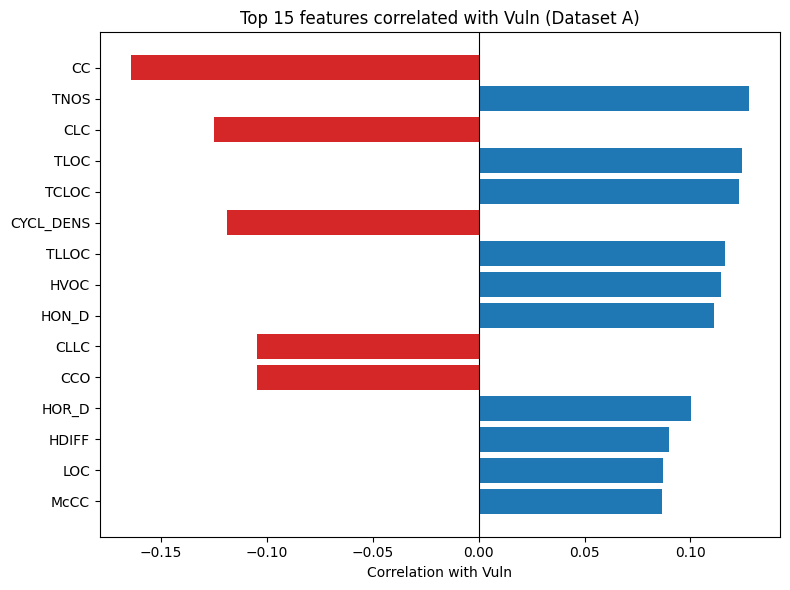

CC          -0.164153
TNOS         0.127687
CLC         -0.124930
TLOC         0.124477
TCLOC        0.123102
CYCL_DENS   -0.118996
TLLOC        0.116232
HVOC         0.114379
HON_D        0.111225
CLLC        -0.104734
CCO         -0.104520
HOR_D        0.100212
HDIFF        0.089840
LOC          0.087026
McCC         0.086493
Name: Vuln, dtype: float64


In [8]:
feature_cols_A = [c for c in dataset_A.columns if c not in ["Vuln", "repo", "holdout"]]
corr = dataset_A[feature_cols_A + ["Vuln"]].corr(numeric_only=True)["Vuln"].drop("Vuln")
corr_sorted = corr.reindex(corr.abs().sort_values(ascending=False).index)

plt.figure(figsize=(8, 6))
colors = ["#1f77b4" if val > 0 else "#d62728" for val in corr_sorted.head(15)]
plt.barh(corr_sorted.head(15).index[::-1], corr_sorted.head(15).values[::-1],
          color=colors[::-1])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top 15 features correlated with Vuln (Dataset A)")
plt.xlabel("Correlation with Vuln")
plt.tight_layout()
plt.savefig("correlation_with_vuln_A.png", dpi=150)
plt.show()

print(corr_sorted.head(15))


## Step 5 — Imbalance-handling utilities

All of these are applied **inside** each cross-validation fold, only to that fold's training
portion — never before the split, and never to the holdout set.


In [9]:
def get_class_weights(y):
    """Class weights for sklearn/XGBoost, inversely proportional to class frequency."""
    classes, counts = np.unique(y, return_counts=True)
    total = len(y)
    return {c: total / (len(classes) * cnt) for c, cnt in zip(classes, counts)}


def focal_loss(gamma=2.0, alpha=0.25):
    """Focal loss for the CNN models — down-weights easy (majority-class) examples so the
    rare vulnerable class gets more gradient signal than plain binary cross-entropy gives it."""
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        ce = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * ce, axis=-1))
    return loss_fn


def gaussian_noise_oversample(X, y, minority_class=1, n_synthetic=None, noise_scale=0.05,
                                random_state=42):
    """Create synthetic minority samples by jittering real minority rows with small Gaussian
    noise scaled to each feature's standard deviation. Clips negative values for count-type
    features (LOC, NOS, etc. can't go below 0)."""
    rng = np.random.default_rng(random_state)
    minority_mask = y == minority_class
    X_min = X[minority_mask]
    if n_synthetic is None:
        n_synthetic = (y == (1 - minority_class)).sum() - minority_mask.sum()
        n_synthetic = max(n_synthetic, 0)
    if n_synthetic == 0:
        return X, y
    stds = X_min.std(axis=0)
    idx = rng.integers(0, len(X_min), size=n_synthetic)
    noise = rng.normal(0, noise_scale, size=(n_synthetic, X.shape[1])) * stds
    synthetic = X_min[idx] + noise
    synthetic = np.clip(synthetic, a_min=0, a_max=None)
    X_new = np.vstack([X, synthetic])
    y_new = np.concatenate([y, np.full(n_synthetic, minority_class)])
    return X_new, y_new


def smote_oversample(X, y, random_state=42):
    sm = SMOTE(random_state=random_state)
    return sm.fit_resample(X, y)


## Step 6 — Evaluation metrics helper

Accuracy/F1 alone can look good while hiding poor minority-class recall at this imbalance
level — PR-AUC and MCC are reported for every model alongside them.


In [10]:
def evaluate(y_true, y_pred, y_proba):
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
        "pr_auc":    average_precision_score(y_true, y_proba),
        "mcc":       matthews_corrcoef(y_true, y_pred),
    }


def summarize_cv(fold_results):
    df = pd.DataFrame(fold_results)
    return df.mean().round(4), df.std().round(4)


## Step 7 — Baseline classical models (repo-grouped CV, Dataset A training pool)

`StratifiedGroupKFold` ensures no repo's functions are ever split across train and test within
a fold — the same leakage concern as the holdout split, just applied to the in-distribution
evaluation too.


In [11]:
train_A = dataset_A[~dataset_A["holdout"]].reset_index(drop=True)
holdout_A = dataset_A[dataset_A["holdout"]].reset_index(drop=True)

feature_cols_A = [c for c in dataset_A.columns if c not in ["Vuln", "repo", "holdout"]]

X_train_full = train_A[feature_cols_A].fillna(0).values
y_train_full = train_A["Vuln"].values
groups_full  = train_A["repo"].values

X_holdout = holdout_A[feature_cols_A].fillna(0).values
y_holdout = holdout_A["Vuln"].values

print("Training pool:", X_train_full.shape, " | Holdout:", X_holdout.shape)


Training pool: (11344, 35)  | Holdout: (709, 35)


In [12]:
def run_baseline_cv(model_fn, X, y, groups, resample=None, n_splits=5):
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_scores = []
    for tr_idx, te_idx in sgkf.split(X, y, groups):
        X_tr, y_tr = X[tr_idx], y[tr_idx]
        X_te, y_te = X[te_idx], y[te_idx]

        if resample == "smote":
            X_tr, y_tr = smote_oversample(X_tr, y_tr)
        elif resample == "gaussian":
            X_tr, y_tr = gaussian_noise_oversample(X_tr, y_tr)

        model = model_fn(y_tr)
        model.fit(X_tr, y_tr)
        y_proba = model.predict_proba(X_te)[:, 1]
        y_pred = model.predict(X_te)
        fold_scores.append(evaluate(y_te, y_pred, y_proba))
    mean_scores, std_scores = summarize_cv(fold_scores)
    return mean_scores, std_scores


def make_xgb(y_tr, use_class_weight=False):
    spw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1) if use_class_weight else 1.0
    return XGBClassifier(scale_pos_weight=spw, eval_metric="logloss", n_estimators=200)

def make_rf(y_tr, use_class_weight=False):
    return RandomForestClassifier(
        n_estimators=300, class_weight="balanced" if use_class_weight else None, random_state=42
    )

def make_bagging(y_tr, use_class_weight=False):
    return BaggingClassifier(n_estimators=100, random_state=42)


baseline_results = {}
configs = [
    ("XGBoost + class_weight",  lambda y_tr: make_xgb(y_tr, use_class_weight=True), None),
    ("XGBoost + SMOTE",         lambda y_tr: make_xgb(y_tr, use_class_weight=False), "smote"),
    ("XGBoost + Gaussian noise",lambda y_tr: make_xgb(y_tr, use_class_weight=False), "gaussian"),
    ("RandomForest + class_weight", lambda y_tr: make_rf(y_tr, use_class_weight=True), None),
    ("Bagging (no resampling)", lambda y_tr: make_bagging(y_tr), None),
]

for name, model_fn, resample in configs:
    mean_scores, std_scores = run_baseline_cv(model_fn, X_train_full, y_train_full, groups_full, resample=resample)
    baseline_results[name] = mean_scores
    print(f"\n{name}")
    print(mean_scores.to_string())

baseline_df = pd.DataFrame(baseline_results).T
baseline_df



XGBoost + class_weight
accuracy     0.7803
precision    0.2782
recall       0.1562
f1           0.1740
pr_auc       0.2458
mcc          0.0887

XGBoost + SMOTE
accuracy     0.7767
precision    0.2445
recall       0.1145
f1           0.1293
pr_auc       0.2350
mcc          0.0461

XGBoost + Gaussian noise
accuracy     0.7786
precision    0.4033
recall       0.1145
f1           0.1387
pr_auc       0.2447
mcc          0.0916

RandomForest + class_weight
accuracy     0.7888
precision    0.3741
recall       0.0561
f1           0.0886
pr_auc       0.3144
mcc          0.0486

Bagging (no resampling)
accuracy     0.7802
precision    0.4510
recall       0.0854
f1           0.1132
pr_auc       0.2378
mcc          0.0711


,accuracy,precision,recall,f1,pr_auc,mcc
XGBoost + class_weight,0.7803,0.2782,0.1562,0.1740,0.2458,0.0887
XGBoost + SMOTE,0.7767,0.2445,0.1145,0.1293,0.2350,0.0461
XGBoost + Gaussian noise,0.7786,0.4033,0.1145,0.1387,0.2447,0.0916
RandomForest + class_weight,0.7888,0.3741,0.0561,0.0886,0.3144,0.0486
Bagging (no resampling),0.7802,0.4510,0.0854,0.1132,0.2378,0.0711


## Step 8 — Stacked CNN model (your existing architecture, reused)

Same VGG16/19/AlexNet/ResNet/LSTM base learners + logistic-regression meta-learner from your
original notebook, wired into the repo-grouped split instead of a random `train_test_split`,
with epochs reduced (1000 → 40) so a full CV pass is actually feasible in a week, and
`class_weight` applied during training.


In [13]:
def build_vgg16(input_len, num_classes=2, learning_rate=0.001, momentum=0.9):
    model = Sequential()
    model.add(Conv1D(64, 2, activation="relu", input_shape=(input_len, 1)))
    model.add(Conv1D(64, 2, activation="relu", padding="same"))
    model.add(MaxPooling1D())
    model.add(Conv1D(128, 2, activation="relu", padding="same"))
    model.add(Conv1D(128, 2, activation="relu", padding="same"))
    model.add(MaxPooling1D())
    model.add(Conv1D(256, 2, activation="relu", padding="same"))
    model.add(Conv1D(256, 2, activation="relu", padding="same"))
    model.add(MaxPooling1D())
    model.add(Flatten())
    model.add(Dense(512, activation="relu"))
    model.add(Dropout(0.5))
    model.add(Dense(128, activation="relu"))
    model.add(Dense(num_classes, activation="sigmoid"))
    opt = SGD(learning_rate=learning_rate, momentum=momentum)
    model.compile(loss="binary_crossentropy", optimizer=opt, metrics=["accuracy"])
    return model


def build_alexnet(input_len, num_classes=2, learning_rate=0.001, momentum=0.9):
    model = Sequential()
    model.add(Conv1D(96, 5, activation="relu", input_shape=(input_len, 1)))
    model.add(MaxPooling1D())
    model.add(Conv1D(256, 2, activation="relu", padding="same"))
    model.add(MaxPooling1D())
    model.add(Conv1D(384, 2, activation="relu", padding="same"))
    model.add(Flatten())
    model.add(Dense(512, activation="relu"))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation="sigmoid"))
    opt = SGD(learning_rate=learning_rate, momentum=momentum)
    model.compile(loss="binary_crossentropy", optimizer=opt, metrics=["accuracy"])
    return model


def build_lstm(input_len, num_classes=2, learning_rate=0.001, momentum=0.9):
    input_layer = Input(shape=(input_len, 1))
    conv1 = Conv1D(filters=35, kernel_size=4, strides=1, activation="relu")(input_layer)
    pool1 = MaxPooling1D(pool_size=2)(conv1)
    lstm1 = LSTM(35)(pool1)
    output_layer = Dense(num_classes, activation="sigmoid")(lstm1)
    model = Model(inputs=input_layer, outputs=output_layer)
    opt = SGD(learning_rate=learning_rate, momentum=momentum)
    model.compile(loss="binary_crossentropy", optimizer=opt, metrics=["accuracy"])
    return model


CNN_BUILDERS = {"vgg16": build_vgg16, "alexnet": build_alexnet, "lstm": build_lstm}
EPOCHS = 40   # reduced from 1000 in the original notebook — keeps this runnable in a week
BATCH_SIZE = 128


In [14]:
def run_stacked_cnn_cv(X, y, groups, n_splits=5):
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_scores = []

    for tr_idx, te_idx in sgkf.split(X, y, groups):
        X_tr, y_tr = X[tr_idx], y[tr_idx]
        X_te, y_te = X[te_idx], y[te_idx]

        scaler = MinMaxScaler()
        X_tr_scaled = scaler.fit_transform(X_tr).reshape(-1, X_tr.shape[1], 1)
        X_te_scaled = scaler.transform(X_te).reshape(-1, X_te.shape[1], 1)

        y_tr_cat = to_categorical(y_tr, num_classes=2)
        class_weights = get_class_weights(y_tr)

        base_preds_tr, base_preds_te = [], []
        for name, builder in CNN_BUILDERS.items():
            model = builder(X_tr.shape[1])
            model.fit(X_tr_scaled, y_tr_cat, batch_size=BATCH_SIZE, epochs=EPOCHS,
                      verbose=0, class_weight=class_weights, validation_split=0.1)
            base_preds_tr.append(model.predict(X_tr_scaled, verbose=0)[:, 1])
            base_preds_te.append(model.predict(X_te_scaled, verbose=0)[:, 1])

        stack_X_tr = np.column_stack(base_preds_tr)
        stack_X_te = np.column_stack(base_preds_te)

        meta = LogisticRegression(max_iter=1000, class_weight="balanced")
        meta.fit(stack_X_tr, y_tr)
        y_proba = meta.predict_proba(stack_X_te)[:, 1]
        y_pred = meta.predict(stack_X_te)
        fold_scores.append(evaluate(y_te, y_pred, y_proba))

    return summarize_cv(fold_scores)

cnn_mean, cnn_std = run_stacked_cnn_cv(X_train_full, y_train_full, groups_full)
print("Stacked CNN (in-distribution CV):")
print(cnn_mean.to_string())
baseline_results["Stacked CNN (VGG16+AlexNet+LSTM)"] = cnn_mean


d:\VS.codedata\JS-Cyber\cyber\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


d:\VS.codedata\JS-Cyber\cyber\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
d:\VS.codedata\JS-Cyber\cyber\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
d:\VS.codedata\JS-Cyber\cyber\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__i

Stacked CNN (in-distribution CV):
accuracy     0.5376
precision    0.2332
recall       0.5857
f1           0.2817
pr_auc       0.2511
mcc          0.0927


## Step 9 — In-distribution results summary


In [15]:
results_df = pd.DataFrame(baseline_results).T
results_df = results_df.sort_values("pr_auc", ascending=False)
print("In-distribution results (repo-grouped CV on the 73-repo training pool):")
results_df


In-distribution results (repo-grouped CV on the 73-repo training pool):


,accuracy,precision,recall,f1,pr_auc,mcc
RandomForest + class_weight,0.7888,0.3741,0.0561,0.0886,0.3144,0.0486
Stacked CNN (VGG16+AlexNet+LSTM),0.5376,0.2332,0.5857,0.2817,0.2511,0.0927
XGBoost + class_weight,0.7803,0.2782,0.1562,0.1740,0.2458,0.0887
XGBoost + Gaussian noise,0.7786,0.4033,0.1145,0.1387,0.2447,0.0916
Bagging (no resampling),0.7802,0.4510,0.0854,0.1132,0.2378,0.0711
XGBoost + SMOTE,0.7767,0.2445,0.1145,0.1293,0.2350,0.0461


## Step 10 — Headline experiment: generalization to the 20 held-out repos

Train each model on the **entire** 73-repo pool, then test purely on the 20 Ferenc-only repos
that neither model has seen in any form. This is the actual new result — the gap between this
score and the in-distribution CV score above is what nobody in the prior literature reports.


In [16]:
def train_final_and_test_holdout(model_fn, X_tr, y_tr, X_ho, y_ho, resample=None):
    if resample == "smote":
        X_tr, y_tr = smote_oversample(X_tr, y_tr)
    elif resample == "gaussian":
        X_tr, y_tr = gaussian_noise_oversample(X_tr, y_tr)
    model = model_fn(y_tr)
    model.fit(X_tr, y_tr)
    y_proba = model.predict_proba(X_ho)[:, 1]
    y_pred = model.predict(X_ho)
    return evaluate(y_ho, y_pred, y_proba)


holdout_results = {}
for name, model_fn, resample in configs:
    holdout_results[name] = train_final_and_test_holdout(
        model_fn, X_train_full, y_train_full, X_holdout, y_holdout, resample=resample
    )
    print(name, "->", holdout_results[name])


XGBoost + class_weight -> {'accuracy': 0.8110014104372355, 'precision': 0.4444444444444444, 'recall': 0.12307692307692308, 'f1': 0.1927710843373494, 'pr_auc': 0.30176471905355773, 'mcc': 0.15605052995408408}
XGBoost + SMOTE -> {'accuracy': 0.8265162200282088, 'precision': 0.6521739130434783, 'recall': 0.11538461538461539, 'f1': 0.19607843137254902, 'pr_auc': 0.31875155839975383, 'mcc': 0.22184035720616177}
XGBoost + Gaussian noise -> {'accuracy': 0.8208744710860366, 'precision': 0.5714285714285714, 'recall': 0.09230769230769231, 'f1': 0.15894039735099338, 'pr_auc': 0.3271424202678344, 'mcc': 0.17521154249722343}
RandomForest + class_weight -> {'accuracy': 0.8081805359661495, 'precision': 0.3125, 'recall': 0.038461538461538464, 'f1': 0.0684931506849315, 'pr_auc': 0.27974409317044735, 'mcc': 0.05071075284103763}
Bagging (no resampling) -> {'accuracy': 0.8124118476727785, 'precision': 0.4117647058823529, 'recall': 0.05384615384615385, 'f1': 0.09523809523809523, 'pr_auc': 0.288146438300773

In [17]:
def train_final_stacked_cnn(X_tr, y_tr, X_ho, y_ho):
    scaler = MinMaxScaler()
    X_tr_scaled = scaler.fit_transform(X_tr).reshape(-1, X_tr.shape[1], 1)
    X_ho_scaled = scaler.transform(X_ho).reshape(-1, X_ho.shape[1], 1)
    y_tr_cat = to_categorical(y_tr, num_classes=2)
    class_weights = get_class_weights(y_tr)

    base_preds_tr, base_preds_ho = [], []
    for name, builder in CNN_BUILDERS.items():
        model = builder(X_tr.shape[1])
        model.fit(X_tr_scaled, y_tr_cat, batch_size=BATCH_SIZE, epochs=EPOCHS,
                  verbose=0, class_weight=class_weights, validation_split=0.1)
        base_preds_tr.append(model.predict(X_tr_scaled, verbose=0)[:, 1])
        base_preds_ho.append(model.predict(X_ho_scaled, verbose=0)[:, 1])

    stack_X_tr = np.column_stack(base_preds_tr)
    stack_X_ho = np.column_stack(base_preds_ho)
    meta = LogisticRegression(max_iter=1000, class_weight="balanced")
    meta.fit(stack_X_tr, y_tr)
    y_proba = meta.predict_proba(stack_X_ho)[:, 1]
    y_pred = meta.predict(stack_X_ho)
    return evaluate(y_ho, y_pred, y_proba)

holdout_results["Stacked CNN (VGG16+AlexNet+LSTM)"] = train_final_stacked_cnn(
    X_train_full, y_train_full, X_holdout, y_holdout
)
holdout_df = pd.DataFrame(holdout_results).T
holdout_df


d:\VS.codedata\JS-Cyber\cyber\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,accuracy,precision,recall,f1,pr_auc,mcc
XGBoost + class_weight,0.811001,0.444444,0.123077,0.192771,0.301765,0.156051
XGBoost + SMOTE,0.826516,0.652174,0.115385,0.196078,0.318752,0.221840
XGBoost + Gaussian noise,0.820874,0.571429,0.092308,0.158940,0.327142,0.175212
RandomForest + class_weight,0.808181,0.312500,0.038462,0.068493,0.279744,0.050711
Bagging (no resampling),0.812412,0.411765,0.053846,0.095238,0.288146,0.092516
Stacked CNN (VGG16+AlexNet+LSTM),0.339915,0.202465,0.884615,0.329513,0.297498,0.099109


## Step 11 — Generalization gap: in-distribution vs. held-out

This table is the actual finding of the project.


                                  in_distribution_pr_auc  holdout_pr_auc  \
XGBoost + SMOTE                                   0.2350        0.318752   
XGBoost + Gaussian noise                          0.2447        0.327142   
XGBoost + class_weight                            0.2458        0.301765   
Bagging (no resampling)                           0.2378        0.288146   
Stacked CNN (VGG16+AlexNet+LSTM)                  0.2511        0.297498   
RandomForest + class_weight                       0.3144        0.279744   

                                  generalization_gap  
XGBoost + SMOTE                            -0.083752  
XGBoost + Gaussian noise                   -0.082442  
XGBoost + class_weight                     -0.055965  
Bagging (no resampling)                    -0.050346  
Stacked CNN (VGG16+AlexNet+LSTM)           -0.046398  
RandomForest + class_weight                 0.034656  


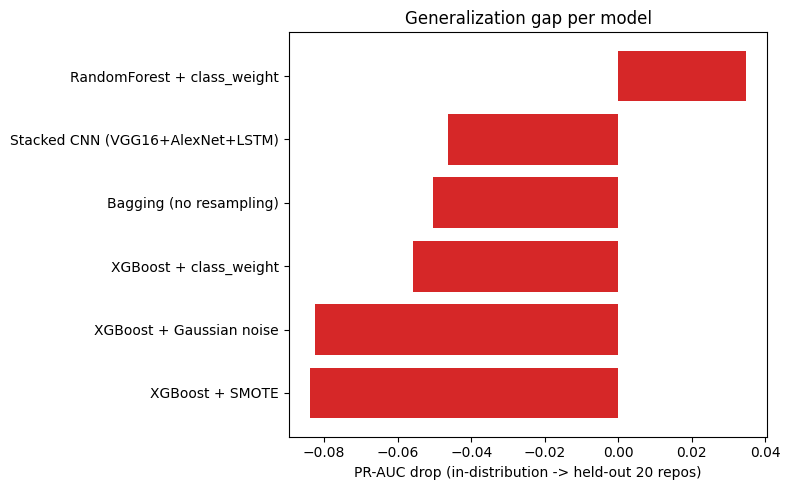

In [18]:
gap_df = pd.DataFrame({
    "in_distribution_pr_auc": results_df["pr_auc"],
    "holdout_pr_auc": holdout_df["pr_auc"],
})
gap_df["generalization_gap"] = gap_df["in_distribution_pr_auc"] - gap_df["holdout_pr_auc"]
gap_df = gap_df.sort_values("generalization_gap")
print(gap_df)

plt.figure(figsize=(8, 5))
plt.barh(gap_df.index, gap_df["generalization_gap"], color="#d62728")
plt.xlabel("PR-AUC drop (in-distribution -> held-out 20 repos)")
plt.title("Generalization gap per model")
plt.tight_layout()
plt.savefig("generalization_gap.png", dpi=150)
plt.show()


## Step 12 — Secondary experiment: do the extra 34 columns help? (Dataset B, 73-repo overlap only)

Same repo-grouped CV, restricted to the 73 overlapping repos, comparing the 44-metric-only
view against the full 78-column view. This never touches the 20-repo holdout.


In [19]:
feature_cols_B_44 = [c for c in shared_metric_cols if c in dataset_B.columns and c != "Vuln"]
feature_cols_B_full = [c for c in dataset_B.columns if c not in ["Vuln", "repo"]]

X_B = dataset_B[feature_cols_B_44].fillna(0).values
X_B_full = dataset_B[feature_cols_B_full].fillna(0).values
y_B = dataset_B["Vuln"].values
groups_B = dataset_B["repo"].values

mean_44, _ = run_baseline_cv(lambda y_tr: make_xgb(y_tr, True), X_B, y_B, groups_B)
mean_78, _ = run_baseline_cv(lambda y_tr: make_xgb(y_tr, True), X_B_full, y_B, groups_B)

print("XGBoost, 44 shared metrics only (73-repo overlap):")
print(mean_44.to_string())
print("\nXGBoost, all 78 columns (73-repo overlap):")
print(mean_78.to_string())
print(f"\nPR-AUC change from adding the 34 extra columns: {mean_78['pr_auc'] - mean_44['pr_auc']:+.4f}")


XGBoost, 44 shared metrics only (73-repo overlap):
accuracy     0.8105
precision    0.1804
recall       0.1018
f1           0.1263
pr_auc       0.2304
mcc          0.0381

XGBoost, all 78 columns (73-repo overlap):
accuracy     0.7882
precision    0.3230
recall       0.1476
f1           0.1919
pr_auc       0.3076
mcc          0.1029

PR-AUC change from adding the 34 extra columns: +0.0772


## Summary

- **In-distribution results** (`results_df`): how every model performs with repo-grouped CV on the 73-repo training pool — directly comparable to prior published numbers.
- **Holdout results** (`holdout_df`): the same models tested on 20 repos they've never seen at all.
- **Generalization gap** (`gap_df`): the actual new finding — which model holds up best moving from known to unseen code.
- **Dataset B comparison**: whether Viszkok's extra process/warning columns add anything on top of the shared 44 metrics.

Next steps beyond this notebook: write up the results into the final report, and optionally
wrap the best-performing model + a static-metric extractor into a small script that takes a
raw `.js` file and outputs a per-function risk score for a live demo.
